# Lab 1 — Observabilidad: ETL + estadística + outliers

**Modalidad:** guiado · **Duración:** ~12 min
**Datasets:** `metrics_timeseries.csv`, `incidents.csv`, `slo_burn.csv`

## Objetivo general
Aprender el ciclo ETL con pandas y las primeras medidas de **estadística descriptiva** sobre series temporales de observabilidad: media, mediana, percentiles y **dispersión**. Detectar NaN y errores del exporter.

## Entregable
Un mini-reporte con 3 KPIs por servicio y un gráfico por KPI, en este notebook.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 4)

DATA = Path('..') / 'data'
metrics = pd.read_csv(DATA / 'metrics_timeseries.csv', parse_dates=['ts'])
incidents = pd.read_csv(DATA / 'incidents.csv', parse_dates=['opened_at', 'resolved_at'])
burn = pd.read_csv(DATA / 'slo_burn.csv', parse_dates=['ts'])
metrics.shape, incidents.shape, burn.shape

((972015, 9), (60, 9), (1118, 5))

## 1. Diagnóstico — mapa de calor de faltantes


**Qué buscamos:** aislar los datos físicamente imposibles (latencias negativas,
CPU > 100 %) y los NaN, para que el análisis posterior refleje el servicio real.

**Por qué:** la media y los percentiles se distorsionan con valores basura
y reportan disponibilidad falsa. Un solo `latency_ms = -50` basta para
arrastrar la media hacia abajo.

**Reglas que aplicamos:**
- `latency_ms < 0` → drop (error del exporter).
- `latency_ms > 10 000` → drop.
- `cpu_pct < 0 | > 100` → drop.
- `NaN` en numéricas → imputar con la **mediana** del servicio (es robusta a outliers).



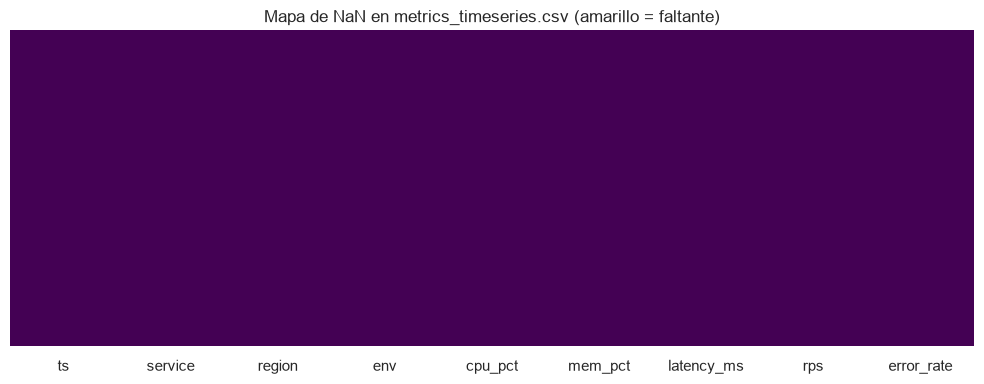

In [2]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(metrics.isnull(), cbar=False, yticklabels=False, cmap='viridis')
ax.set_title('Mapa de NaN en metrics_timeseries.csv (amarillo = faltante)')
plt.tight_layout()
plt.savefig('../html/lab1_fig1_nan.png', dpi=110, bbox_inches='tight')
plt.show()

## 2. Limpieza — qué datos faltan y cómo arreglarlos

| Columna       | Qué falta                                | Cómo arreglar                                |
|---------------|------------------------------------------|----------------------------------------------|
| `latency_ms`  | ~0.3 % NaN + 0.5 % con valores < 0       | Drop errores + imputar con la **mediana**     |
| `cpu_pct`     | ~0.2 % NaN + 0.2 % con valores > 100     | Drop errores + imputar con la **mediana**     |
| `error_rate`  | OK (ya acotado 0–1)                       | Sin cambios                                   |

In [3]:
def clean_numeric(df, col, lo, hi):
    bad = (df[col] < lo) | (df[col] > hi)
    print(f'{col}: {bad.sum()} valores imposibles borrados')
    df = df.loc[~bad].copy()
    med = df[col].median()
    df[col] = df[col].fillna(med)
    return df

metrics = clean_numeric(metrics, 'latency_ms', 0, 10_000)
metrics = clean_numeric(metrics, 'cpu_pct', 0, 100)
print('shape limpio:', metrics.shape)

latency_ms: 4890 valores imposibles borrados
cpu_pct: 1915 valores imposibles borrados


shape limpio: (965210, 9)


## 3. Distribución — histograma + KDE + líneas de media / mediana

**Qué comparamos:** cómo cambia la distribución de latencia al limpiar outliers.

**Por qué:** en el histograma crudo verás la cola izquierda negativa revelando los errores del exporter. En el limpio, media y mediana se acercan.

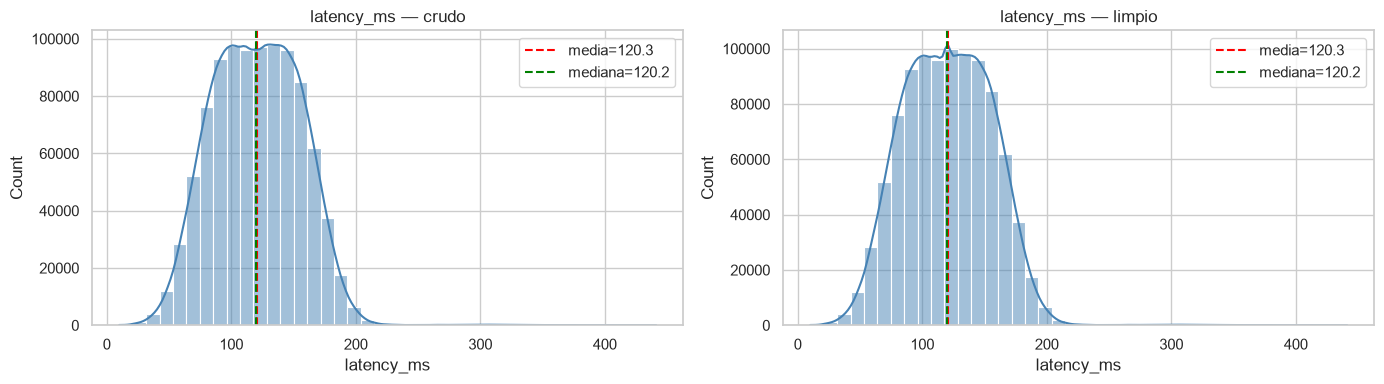

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for i, (label, lo, hi) in enumerate([('crudo', 0, 1500), ('limpio', 0, 600)]):
    ax[i].set_title(f'latency_ms — {label}')
    if label == 'crudo':
        s = pd.read_csv(DATA / 'metrics_timeseries.csv', parse_dates=['ts'])['latency_ms'].dropna()
    else:
        s = metrics['latency_ms']
    s = s[(s >= lo) & (s <= hi)]
    sns.histplot(s, kde=True, bins=40, color='steelblue', ax=ax[i])
    ax[i].axvline(s.mean(), color='red', linestyle='--', label=f'media={s.mean():.1f}')
    ax[i].axvline(s.median(), color='green', linestyle='--', label=f'mediana={s.median():.1f}')
    ax[i].legend()
plt.tight_layout()
plt.savefig('../html/lab1_fig2_latency_dist.png', dpi=110, bbox_inches='tight')
plt.show()

## 4. Boxplot por servicio (outliers visuales)


**Qué buscamos:** saber qué servicios están sufriendo incidentes reales.

**Por qué importa Tukey (IQR × 1.5):**
- Media y p50 esconden los picos.
- La mediana es robusta, pero necesitamos un criterio operativo para etiquetar
  un valor como "anómalo" y actuar.

**Lectura del boxplot:**
- Caja = percentiles 25–75 (IQR).
- Rayita dentro = mediana.
- Bigotes = `Q3 + 1.5·IQR` (arriba) y `Q1 - 1.5·IQR` (abajo).
- Puntos fuera del bigote = outliers. Solo arriba = incidente unilateral.


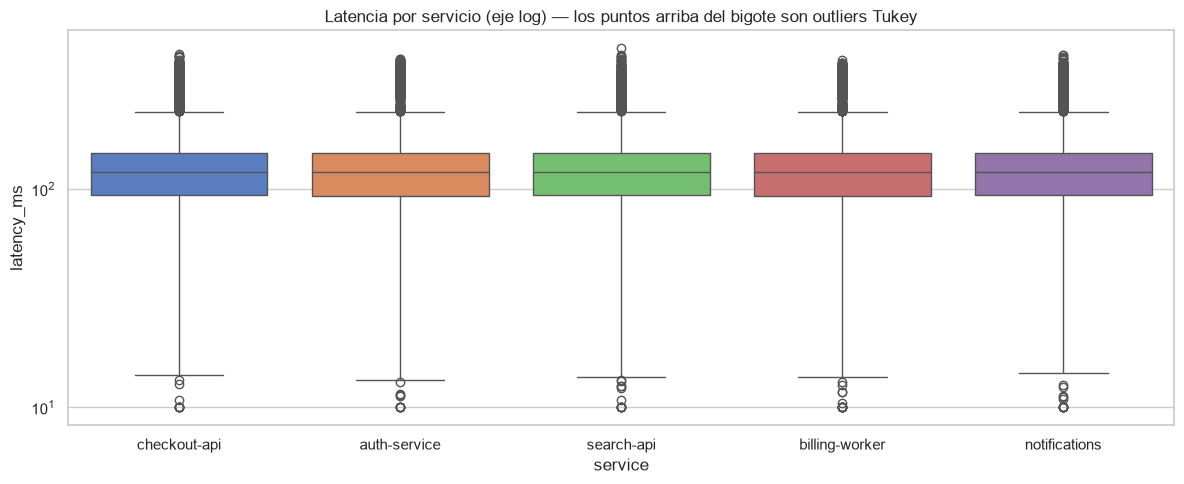

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=metrics, x='service', y='latency_ms', hue='service', legend=False, ax=ax)
ax.set_yscale('log')
ax.set_title('Latencia por servicio (eje log) — los puntos arriba del bigote son outliers Tukey')
plt.tight_layout()
plt.savefig('../html/lab1_fig3_boxplot.png', dpi=110, bbox_inches='tight')
plt.show()

## 5. Regla de Tukey — explicita para `latency_ms`

**Qué buscamos:** traducir la visualización del boxplot a una métrica operable.

**Por qué:** un operador necesita saber *cuántos* outliers por servicio, no solo *verlos*.

In [6]:
def iqr_outliers(df, col, by):
    q1 = df.groupby(by)[col].quantile(0.25)
    q3 = df.groupby(by)[col].quantile(0.75)
    iqr = q3 - q1
    low = (q1 - 1.5 * iqr).rename('low')
    high = (q3 + 1.5 * iqr).rename('high')
    return pd.concat([q1.rename('q1'), q3.rename('q3'), iqr.rename('iqr'), low, high], axis=1).round(2)

bounds = iqr_outliers(metrics, 'latency_ms', 'service')
bounds

,q1,q3,iqr,low,high
service,,,,,
auth-service,93.4,146.8,53.4,13.30,226.90
billing-worker,93.4,146.7,53.3,13.45,226.65
checkout-api,93.5,146.9,53.4,13.40,227.00
notifications,93.5,146.8,53.3,13.55,226.75
search-api,93.5,146.8,53.3,13.55,226.75


In [7]:
def flag_outliers(df, col, by):
    q1 = df.groupby(by)[col].quantile(0.25)
    q3 = df.groupby(by)[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return ((df[col] < df[by].map(low)) | (df[col] > df[by].map(high)))

metrics['is_outlier'] = flag_outliers(metrics, 'latency_ms', 'service')
print(f"Outliers Tukey en latency_ms: {metrics['is_outlier'].sum():,} "
      f"({metrics['is_outlier'].mean():.2%})")
metrics.groupby('service')['is_outlier'].mean().round(4).sort_values(ascending=False)

Outliers Tukey en latency_ms: 1,765 (0.18%)


service
notifications     0.0019
auth-service      0.0018
checkout-api      0.0018
search-api        0.0018
billing-worker    0.0017
Name: is_outlier, dtype: float64

## 6. Insight ejecutivo — cabeza de línea por carga

**Qué comunicamos:** el SLO del servicio top con más outliers y por qué.

**Por qué:** el boxplot y los números sirven al equipo, pero el director necesita una sola cifra. Cerramos con **p95** y **burn-rate 5x**.

In [8]:
agg = metrics.groupby('service').agg(
    cpu_mean=('cpu_pct', 'mean'),
    cpu_p95=('cpu_pct', lambda s: s.quantile(0.95)),
    lat_mean=('latency_ms', 'mean'),
    p95_lat=('latency_ms', lambda s: s.quantile(0.95)),
    err_rate=('error_rate', 'mean'),
    rps_total=('rps', 'sum'),
    outliers=('is_outlier', 'sum'),
)
agg.round(3)

,cpu_mean,cpu_p95,lat_mean,p95_lat,err_rate,rps_total,outliers
service,,,,,,,
auth-service,35.207,52.47,120.340,176.0,0.002,154544317.0,346
billing-worker,34.843,52.09,120.206,175.7,0.002,154421265.0,337
checkout-api,35.702,53.23,120.453,176.0,0.002,154464227.0,357
notifications,34.572,53.05,120.379,175.9,0.002,154454389.0,374
search-api,35.823,53.18,120.354,175.8,0.002,154373850.0,351


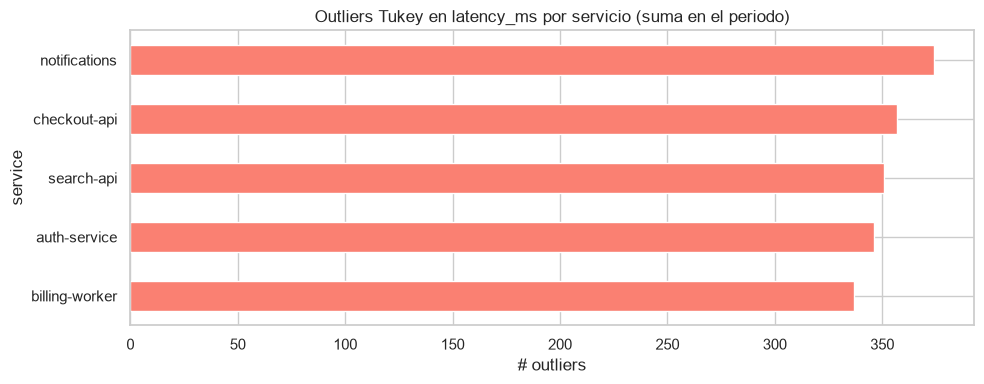

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
agg['outliers'].sort_values().plot(kind='barh', color='salmon', ax=ax)
ax.set_title('Outliers Tukey en latency_ms por servicio (suma en el periodo)')
ax.set_xlabel('# outliers')
plt.tight_layout()
plt.savefig('../html/lab1_fig4_outliers_per_service.png', dpi=110, bbox_inches='tight')
plt.show()

## Para discutir
- ¿Por qué p95 > media para alertar latencia?
- ¿Cómo se traduce `error_rate` promedio mensual a disponibilidad?
- Outliers = incidente real o sensor roto? Cómo decidir.